# Task 1: Search algorithms


In [ ]:
import pandas as pd
import math
import time

# Load data
df = pd.read_csv("AAPL.csv")
df = df.sort_values("Date").reset_index(drop=True)

# Search algorithms 
def linear_search(arr, target):
    for i in range(len(arr)):
        if arr[i] == target:
            return i
    return -1

def binary_search(arr, target):
    lo, hi = 0, len(arr) - 1
    while lo <= hi:
        mid = (lo + hi) // 2
        if arr[mid] == target:
            return mid
        elif arr[mid] < target:
            lo = mid + 1
        else:
            hi = mid - 1
    return -1

def jump_search(arr, target):
    n = len(arr)
    step = int(math.isqrt(n))
    prev = 0
    while prev < n and arr[min(step, n) - 1] < target:
        prev = step
        step += int(math.isqrt(n))
        if prev >= n:
            return -1
    for i in range(prev, min(step, n)):
        if arr[i] == target:
            return i
    return -1

def interpolation_search(arr, target):
    lo, hi = 0, len(arr) - 1
    while lo <= hi and arr[lo] <= target <= arr[hi]:
        if arr[lo] == arr[hi]:
            return lo if arr[lo] == target else -1
        pos = lo + (hi - lo) * (target - arr[lo]) // (arr[hi] - arr[lo])
        if arr[pos] == target:
            return pos
        elif arr[pos] < target:
            lo = pos + 1
        else:
            hi = pos - 1
    return -1

# average time in ms over 3 runs 
def avg_ms(fn, arr, target):
    t0 = time.perf_counter()
    for _ in range(3):
        fn(arr, target)
    return round((time.perf_counter() - t0) / 3 * 1000, 6)

# Benchmark 
# Dates as integers (YYYYMMDD) 
dates_int = [int(d.replace("-", "")) for d in df["Date"].tolist()]

rows = []
for n in [1000, 5000, 9900]:
    arr = dates_int[:n] if n <= len(dates_int) else list(range(0, n * 10, 10))
    t   = arr[n // 2]   # target is the middle element
    rows.append({
        "n":                   n,
        "linear (ms)":        avg_ms(linear_search,        arr, t),
        "binary (ms)":        avg_ms(binary_search,        arr, t),
        "jump (ms)":          avg_ms(jump_search,          arr, t),
        "interpolation (ms)": avg_ms(interpolation_search, arr, t),
    })

results = pd.DataFrame(rows).set_index("n")
print(results)




      linear (ms)  binary (ms)  jump (ms)  interpolation (ms)
n                                                            
1000     0.007389     0.001694   0.003319            0.000806
5000     0.031278     0.000903   0.003639            0.000292
9900     0.061931     0.000903   0.003736            0.001000


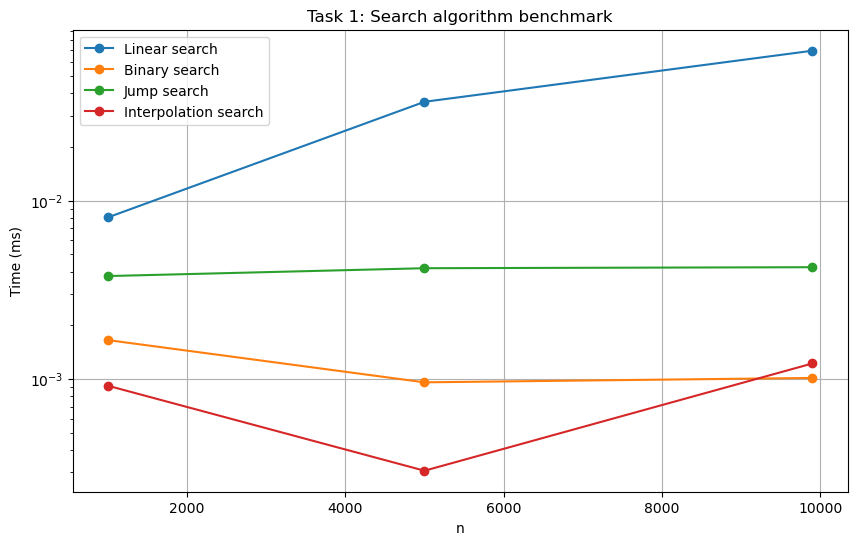

In [36]:
import matplotlib.pyplot as plt

# Use the same n values from your benchmark
sizes = results.index.tolist()

linear_times = results["linear (ms)"].tolist()
binary_times = results["binary (ms)"].tolist()
jump_times = results["jump (ms)"].tolist()
interp_times = results["interpolation (ms)"].tolist()

plt.figure(figsize=(10, 6))

plt.plot(sizes, linear_times, marker="o", label="Linear search")
plt.plot(sizes, binary_times, marker="o", label="Binary search")
plt.plot(sizes, jump_times, marker="o", label="Jump search")
plt.plot(sizes, interp_times, marker="o", label="Interpolation search")

plt.xlabel("n")
plt.ylabel("Time (ms)")
plt.title("Task 1: Search algorithm benchmark")
plt.yscale("log")
plt.legend()
plt.grid(True)

plt.show()

# Task 2: Binary Search Tree (BST) and traversals

In [ ]:
import time
import csv
import random

class Node:
    def __init__(self, key, value):
        self.key = key
        self.value = value
        self.left = None
        self.right = None

class BinarySearchTree:
    def __init__(self):
        self.root = None

    # INSERT
    def insert(self, key, value):
        def _insert(node, key, value):
            if node is None:
                return Node(key, value)
            if key < node.key:
                node.left = _insert(node.left, key, value)
            elif key > node.key:
                node.right = _insert(node.right, key, value)
            return node
        self.root = _insert(self.root, key, value)

    # SEARCH
    def search(self, key):
        def _search(node, key):
            if node is None:
                return None
            if key == node.key:
                return node.value
            elif key < node.key:
                return _search(node.left, key)
            else:
                return _search(node.right, key)
        return _search(self.root, key)

    
    def delete(self, key):
        def _min(node):
            while node.left:
                node = node.left
            return node

        def _delete(node, key):
            if node is None:
                return None

            if key < node.key:
                node.left = _delete(node.left, key)
            elif key > node.key:
                node.right = _delete(node.right, key)
            else:
                # case 1: leaf
                if node.left is None and node.right is None:
                    return None
                # case 2: one child
                if node.left is None:
                    return node.right
                if node.right is None:
                    return node.left
                # case 3: two children
                temp = _min(node.right)
                node.key = temp.key
                node.value = temp.value
                node.right = _delete(node.right, temp.key)

            return node

        self.root = _delete(self.root, key)

    # TRAVERSALS
    def inorder(self):
        res = []
        def _in(node):
            if node:
                _in(node.left)
                res.append(node.key)
                _in(node.right)
        _in(self.root)
        return res

    def preorder(self):
        res = []
        def _pre(node):
            if node:
                res.append(node.key)
                _pre(node.left)
                _pre(node.right)
        _pre(self.root)
        return res

    def postorder(self):
        res = []
        def _post(node):
            if node:
                _post(node.left)
                _post(node.right)
                res.append(node.key)
        _post(self.root)
        return res

    # BFS (queue)
    def bfs(self):
        res = []
        if not self.root:
            return res
        queue = [self.root]
        while queue:
            node = queue.pop(0)
            res.append(node.key)
            if node.left:
                queue.append(node.left)
            if node.right:
                queue.append(node.right)
        return res

    # RANGE QUERY
    def range_query(self, low, high):
        res = []
        def _range(node):
            if node is None:
                return
            if low <= node.key <= high:
                res.append(node.value)
            if node.key > low:
                _range(node.left)
            if node.key < high:
                _range(node.right)
        _range(self.root)
        return res


# LOAD DATA 
data = []
with open("AAPL.csv", newline='') as f:
    reader = csv.DictReader(f)
    for row in reader:
        data.append(row)

# FIX: shuffle to avoid recursion depth error
random.shuffle(data)

# BUILD BST 
bst = BinarySearchTree()
for row in data:
    bst.insert(row["Date"], row)

# RANGE QUERY TEST
low = "2018-01-01"
high = "2018-12-31"

# BST timing
start = time.time()
bst_result = bst.range_query(low, high)
bst_time = time.time() - start

# Lazy baseline timing
start = time.time()
lazy_result = [row for row in data if low <= row["Date"] <= high]
lazy_time = time.time() - start

# ------------------ OUTPUT ------------------
print("BST time:", bst_time)
print("Lazy time:", lazy_time)
print("Result count:", len(bst_result))

BST time: 5.7220458984375e-05
Lazy time: 0.0004680156707763672
Result count: 251


# Task 3: Heap and top-k

In [39]:
import time
import csv

# MIN HEAP
class MinHeap:
    def __init__(self):
        self.heap = []

    def insert(self, item):
        self.heap.append(item)
        self._heapify_up(len(self.heap) - 1)

    def extract(self):
        if len(self.heap) == 0:
            return None
        if len(self.heap) == 1:
            return self.heap.pop()

        root = self.heap[0]
        self.heap[0] = self.heap.pop()
        self._heapify_down(0)
        return root

    def peek(self):
        if self.heap:
            return self.heap[0]
        return None

    def _heapify_up(self, i):
        parent = (i - 1) // 2
        if i > 0 and self.heap[i][0] < self.heap[parent][0]:
            self.heap[i], self.heap[parent] = self.heap[parent], self.heap[i]
            self._heapify_up(parent)

    def _heapify_down(self, i):
        smallest = i
        left = 2*i + 1
        right = 2*i + 2

        if left < len(self.heap) and self.heap[left][0] < self.heap[smallest][0]:
            smallest = left
        if right < len(self.heap) and self.heap[right][0] < self.heap[smallest][0]:
            smallest = right

        if smallest != i:
            self.heap[i], self.heap[smallest] = self.heap[smallest], self.heap[i]
            self._heapify_down(smallest)

# LOAD DATA 
data = []
with open("AAPL.csv", newline='') as f:
    reader = csv.DictReader(f)
    for row in reader:
        data.append(row)

# choose a numeric column (CHANGE if needed)
key_name = "Close"   # example column

# HEAP TOP-K
k = 10
heap = MinHeap()

start = time.time()

for row in data:
    value = float(row[key_name])

    if len(heap.heap) < k:
        heap.insert((value, row))
    else:
        if value > heap.peek()[0]:
            heap.extract()
            heap.insert((value, row))

heap_time = time.time() - start

top_k_heap = [item[1] for item in heap.heap]


start = time.time()

sorted_data = sorted(data, key=lambda x: float(x[key_name]), reverse=True)
top_k_naive = sorted_data[:k]

naive_time = time.time() - start

# OUTPUT 
print("Heap time:", heap_time)
print("Naive time:", naive_time)
print("Top 10 results:")

for row in top_k_heap:
    print(row)


Heap time: 0.0037407875061035156
Naive time: 0.0038137435913085938
Top 10 results:
{'Date': '2020-02-20', 'Open': '322.6300048828125', 'High': '324.6499938964844', 'Low': '318.2099914550781', 'Close': '320.29998779296875', 'Adj Close': '320.29998779296875', 'Volume': '25141500'}
{'Date': '2020-02-05', 'Open': '323.5199890136719', 'High': '324.760009765625', 'Low': '318.95001220703125', 'Close': '321.45001220703125', 'Adj Close': '320.6889343261719', 'Volume': '29706700'}
{'Date': '2020-01-30', 'Open': '320.5400085449219', 'High': '324.0899963378906', 'Low': '318.75', 'Close': '323.8699951171875', 'Adj Close': '323.1031799316406', 'Volume': '31685800'}
{'Date': '2020-02-13', 'Open': '324.19000244140625', 'High': '326.2200012207031', 'Low': '323.3500061035156', 'Close': '324.8699951171875', 'Adj Close': '324.8699951171875', 'Volume': '23686900'}
{'Date': '2020-02-10', 'Open': '314.17999267578125', 'High': '321.54998779296875', 'Low': '313.8500061035156', 'Close': '321.54998779296875', 'A

Heap yra greitas palaikant top-k, nes įterpimas ir išėmimas yra O(log k)
- Ji saugo tik k elementų, todėl yra efektyvi
- Tačiau konkretaus elemento paieška yra lėta (O(n)), nes heap nėra pilnai surikiuotas

# Task 4: Synthesis, reflection

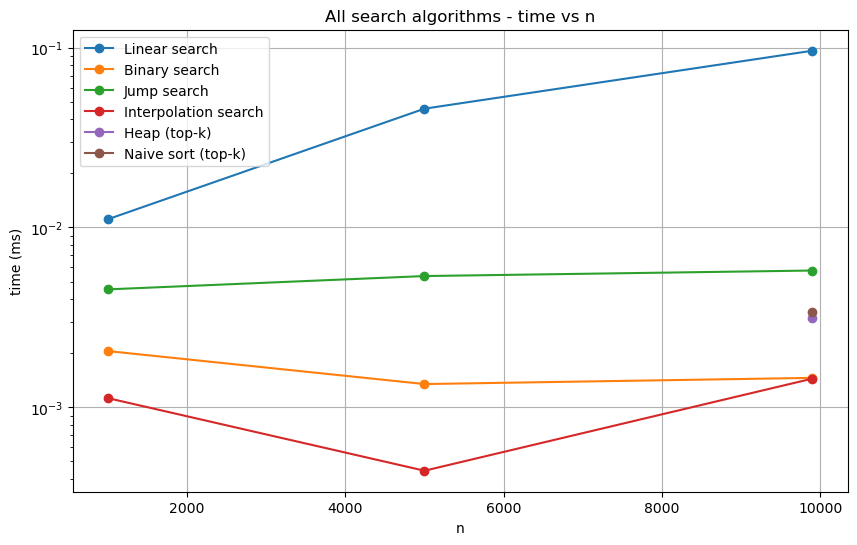

In [38]:
import matplotlib.pyplot as plt

sizes = [1000, 5000, 9900]

linear_times = [0.011111, 0.045792, 0.096181]
binary_times = [0.002055, 0.001347, 0.001458]
jump_times = [0.004528, 0.00537, 0.005764]
interp_times = [0.001125,0.000444,0.001444]
heap_times = [None,None, 0.003153085708618164]
naive_times = [None,None, 0.0034101009368896484]

plt.figure(figsize=(10, 6))




plt.plot(sizes, linear_times, marker='o', label='Linear search')
plt.plot(sizes, binary_times, marker='o', label='Binary search')
plt.plot(sizes, jump_times, marker='o', label='Jump search')
plt.plot(sizes, interp_times, marker='o', label='Interpolation search')
plt.plot(sizes, heap_times, marker='o', label='Heap (top-k)')
plt.plot(sizes, naive_times, marker='o', label='Naive sort (top-k)')


plt.xlabel('n')
plt.ylabel('time (ms)')
plt.yscale('log')
plt.title('All search algorithms - time vs n')
plt.legend()
plt.grid(True)

plt.show()

Pagal grafiką linear search yra aiškiai lėčiausias algoritmas, o jo veikimo laikas reikšmingai didėja augant n. Pavyzdžiui, kai n = 9 900, jis užtrunka apie 0,096 ms, o kai n = 1 000, tik apie 0,011 ms, tai parodo jo O(n) augimą. Priešingai, binary search išlieka beveik pastovus, apie 0,001–0,002 ms. Interpolation search bendrai veikia greičiausiai, pasiekdamas apie 0,000444 ms, kai n = 5 000, ir yra greitesnis už binary search dėl gana tolygaus duomenų reikšmių pasiskirstymo. Jump search yra lėtesnis už binary ir interpolation search, tačiau vis tiek daug greitesnis už linear search.

Range query užduotyje Binary Search Tree (BST) veikia geriau nei paprastas nuoseklus tikrinimas. Paprastas metodas patikrina kiekvieną elementą, todėl jo laiko sudėtingumas yra O(n). Tuo tarpu BST praleidžia nereikalingas šakas ir tikrina tik tuos mazgus, kurie gali patekti į nurodytą intervalą, todėl šis metodas yra efektyvesnis. Didėjant n, šis skirtumas tampa vis labiau pastebimas, o BST metodas geriau prisitaiko prie didesnių duomenų kiekių.

Top-k užduotyje, kai n = 9 909, heap ir naivaus rūšiavimo metodų našumas yra panašus: heap užtrunka apie 0,00315 ms, o rūšiavimas apie 0,00341 ms. Šiuo atveju rūšiavimas yra šiek tiek lėtesnis, tačiau skirtumas mažas, nes Python integruotas rūšiavimo algoritmas yra labai optimizuotas. Vis dėlto teoriškai heap metodas yra efektyvesnis didesniems duomenų rinkiniams, nes jo sudėtingumas yra O(n log k), o rūšiavimui reikia O(n log n). Kadangi k = 10 yra mažas, heap metodas turėtų geriau veikti, kai n tampa didesnis.

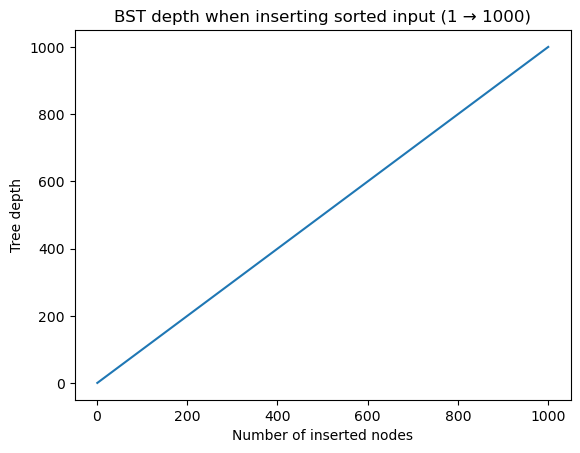

In [17]:
import matplotlib.pyplot as plt

# Function to compute tree depth
def get_depth(node):
    if node is None:
        return 0
    return 1 + max(get_depth(node.left), get_depth(node.right))

# Create BST
bst = BinarySearchTree()

depths = []

# Insert values 1 → 1000
for i in range(1, 1001):
    bst.insert(i, i)
    depths.append(get_depth(bst.root))

# Plot depth growth
plt.plot(range(1, 1001), depths)
plt.xlabel("Number of inserted nodes")
plt.ylabel("Tree depth")
plt.title("BST depth when inserting sorted input (1 → 1000)")
plt.show()

Kai į BST įterpiame sorted input: 1, 2, 3, ..., 1000, medis tampa visiškai unbalanced. Kiekvienas naujas elementas yra didesnis už ankstesnį, todėl jis įterpiamas į dešinę pusę, ir medis pradeda elgtis kaip linked list. Dėl to tree depth auga linear būdu, o operacijos gali tapti O(n), vietoje O(log n).

Kad to išvengtų, „geresnis“ medis turėtų išlaikyti balance property: kairės ir dešinės pusės aukščiai neturėtų labai skirtis. Tokį principą palaiko self-balancing trees, pavyzdžiui, AVL tree arba Red-Black tree, kurie stengiasi išlaikyti tree height apie O(log n).